# Per-cell SFR vs. pixel-level gas surface density

Each point is one Voronoi cell. The x-axis is the 2D gas surface density of the pixel
that cell belongs to (looked up via `pixel_id`). The y-axis is the cell's own SFR.

This is the core relationship the normalizing flow will learn: P(SFR | context).

In [ ]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt

from sfemulator.data.loader import (
    PC_TO_CM, SURFDENS_TO_MSUN_PC2, SFR_SURFDENS_TO_MSUN_YR_KPC2,
    MYR_TO_S, MSOL_TO_G, YR_TO_S, KPC_TO_CM,
)

# Derived conversions for per-cell SFR
SFR_TO_MSUN_MYR = MYR_TO_S / MSOL_TO_G

In [12]:
data = np.load("../output/sfr_context_500.npz")
context = data["context"]     # (n_pixels, 5)
sfr = data["sfr"]             # (n_cells,)
pixel_id = data["pixel_id"]   # (n_cells,)

print(f"Pixels: {context.shape[0]}, Cells: {len(sfr)}, Star-forming: {(sfr > 0).sum()}")

Pixels: 22500, Cells: 1117683, Star-forming: 49392


In [28]:
# Duplicate 2D gas surface density to match each 3D cell via pixel_id
gas_surfdens_per_cell = context[pixel_id, 0]

# Keep only star-forming cells (SFR > 0) for the scatter
sf_mask = sfr > 0
x = gas_surfdens_per_cell[sf_mask]
y = sfr[sf_mask]

print(f"Plotting {sf_mask.sum()} star-forming cells")

Plotting 49392 star-forming cells


In [29]:
# fig, ax = plt.subplots(figsize=(7, 5))

# ax.scatter(
#     np.log10(x * SURFDENS_TO_MSUN_PC2),
#     np.log10(y * SFR_TO_MSUN_MYR),
#     s=5, alpha=0.5,
# )

# ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")
# ax.set_ylabel(r"$\log_{10}\;\dot{M}_\star$ [M$_\odot$ Myr$^{-1}$]")
# ax.set_title("Per-cell SFR vs. pixel gas surface density")

# plt.tight_layout()
# plt.show()

Pixels with SFR > 0: 1308 / 22500


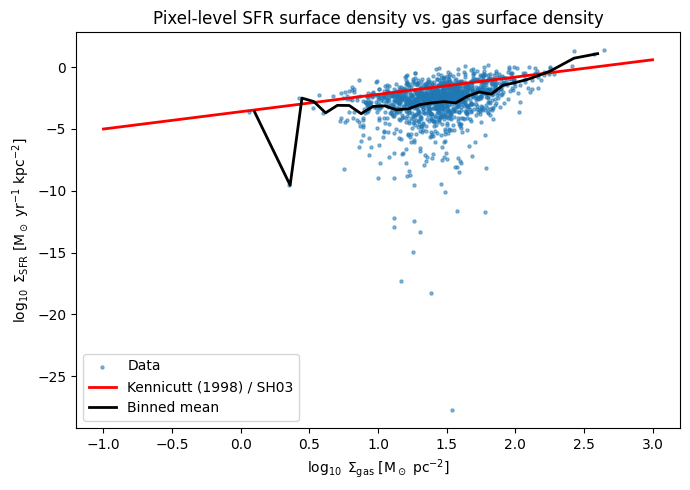

In [30]:
# SFR surface density per pixel: sum cell SFRs in each column / pixel area
pixel_area = (80.0 * PC_TO_CM) ** 2
n_pixels = context.shape[0]

sfr_sum_per_pixel = np.zeros(n_pixels)
np.add.at(sfr_sum_per_pixel, pixel_id, sfr)
sfr_surfdens = sfr_sum_per_pixel / pixel_area

# Only plot pixels that have nonzero SFR
has_sf = sfr_surfdens > 0
gas_surfdens_px = context[has_sf, 0] * SURFDENS_TO_MSUN_PC2
sfr_surfdens_px = sfr_surfdens[has_sf] * SFR_SURFDENS_TO_MSUN_YR_KPC2

print(f"Pixels with SFR > 0: {has_sf.sum()} / {n_pixels}")

# Kennicutt (1998) relation, which SH03 calibrated t0*=2.1 Gyr and beta=0.1 to reproduce.
sig_gas_ks = np.logspace(-1, 3, 200)  # Msun/pc^2
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4  # Msun/yr/kpc^2

# Moving average in log-space bins
log_sig_gas = np.log10(gas_surfdens_px)
log_sig_sfr = np.log10(sfr_surfdens_px)
n_bins = 30
bin_edges = np.linspace(log_sig_gas.min(), log_sig_gas.max(), n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
bin_means = np.full(n_bins, np.nan)
for i in range(n_bins):
    in_bin = (log_sig_gas >= bin_edges[i]) & (log_sig_gas < bin_edges[i + 1])
    if in_bin.sum() > 0:
        bin_means[i] = np.mean(log_sig_sfr[in_bin])

valid = np.isfinite(bin_means)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(log_sig_gas, log_sig_sfr, s=5, alpha=0.5, label="Data")
ax.plot(
    np.log10(sig_gas_ks), np.log10(sig_sfr_ks),
    "r-", lw=2, label="Kennicutt (1998) / SH03",
)
ax.plot(
    bin_centers[valid], bin_means[valid],
    "k-", lw=2, label="Binned mean",
)

ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")
ax.set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
ax.set_title("Pixel-level SFR surface density vs. gas surface density")
ax.legend()

plt.tight_layout()
plt.show()